# Laboratorio de Pandas Avanzado
## Fase 2: Transformación Geoespacial

**Bootcamp Python para Ciencia de Datos — PY4**  
**Módulo 1: Python y Manipulación de Datos**

---

### Contexto

En la Fase 1 limpiamos y procesamos los timestamps del dataset de Divvy. Ahora vamos a trabajar con la otra dimensión: la **ubicación geográfica**.

Cada viaje de Divvy tiene coordenadas de inicio (`start_lat`, `start_lng`) y fin (`end_lat`, `end_lng`). En un DataFrame esos números son columnas más. Para que Pandas entienda que representan posiciones en el espacio — y pueda hacer operaciones como calcular distancias reales o detectar en qué vecindario ocurrió cada viaje — necesitamos convertir el DataFrame en un **GeoDataFrame**.

Eso es lo que hace **GeoPandas**: extiende Pandas con soporte nativo para geometrías espaciales.

En esta sesión vamos a:
1. Cargar el dataset limpio de la Fase 1.
2. Crear objetos geométricos `Point` a partir de las coordenadas.
3. Construir un `GeoDataFrame` y asignarle un CRS (Coordinate Reference System).
4. Descargar los límites reales de los 77 *community areas* de Chicago.
5. Explorar operaciones espaciales básicas.
6. Proyectar a un CRS métrico para calcular distancias reales.
7. Visualizar los viajes sobre el mapa de Chicago.

**Datasets:**
- Viajes Divvy enero 2024 (Fase 1)
- Community Areas de Chicago — fuente: City of Chicago / RandomFractals (GitHub)

---

## 0. Conceptos clave antes de empezar

### Geometrías (Shapely)

GeoPandas usa **Shapely** para representar formas en el espacio. Los tres tipos básicos son:

| Tipo | Representa | Ejemplo en Divvy |
|------|------------|------------------|
| `Point` | Un punto | Ubicación de inicio de un viaje |
| `LineString` | Una línea | Ruta de un viaje |
| `Polygon` | Un área cerrada | Límite de un community area |

Hoy trabajamos principalmente con `Point` y `Polygon`.

### CRS: Sistema de Referencia de Coordenadas

Define cómo se interpretan las coordenadas. Hay dos tipos fundamentales:

- **EPSG:4326 (WGS84)**: latitud y longitud en grados. Es el sistema del GPS. Las unidades son *grados*, no metros.
- **Proyectado (ej. EPSG:26916)**: coordenadas en metros. Necesario para calcular distancias reales.

**Error clásico**: calcular la distancia entre dos `Point` en EPSG:4326 da un número en grados, no en metros. Siempre hay que proyectar antes de medir distancias.

### GeoDataFrame

Un `GeoDataFrame` es un DataFrame normal más una columna especial llamada `geometry` que contiene los objetos geométricos. Todo lo demás — filtrado, groupby, merge — funciona exactamente igual que en Pandas.

## 1. Preparación del entorno

In [1]:
# Instalación si es necesario (descomentar)
# !pip install geopandas shapely matplotlib

In [2]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import urllib.request
import zipfile
import io
import os
import warnings
warnings.filterwarnings('ignore')

print("Librerias cargadas")
print(f"pandas:    {pd.__version__}")
print(f"geopandas: {gpd.__version__}")

Librerias cargadas
pandas:    2.2.2
geopandas: 1.1.3


## 2. Cargar el dataset de la Fase 1

Usamos el archivo `divvy_enero2024_limpio.csv` que guardamos al final de la sesión anterior. Si no existe en disco, la celda lo regenera descargando los datos originales de Divvy.

In [3]:
ARCHIVO_LIMPIO = 'divvy_enero2024_limpio.csv'

if os.path.exists(ARCHIVO_LIMPIO):
    df = pd.read_csv(ARCHIVO_LIMPIO)
    df['started_at'] = pd.to_datetime(df['started_at'], utc=True)
    print(f"Dataset cargado desde archivo: {len(df):,} filas")
else:
    print("Archivo no encontrado. Descargando y procesando desde Divvy...")
    URL = 'https://divvy-tripdata.s3.amazonaws.com/202401-divvy-tripdata.zip'
    req = urllib.request.Request(URL, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req) as r:
        contenido = r.read()
    with zipfile.ZipFile(io.BytesIO(contenido)) as z:
        with z.open(z.namelist()[0]) as f:
            df = pd.read_csv(f)
    df['started_at'] = pd.to_datetime(df['started_at'], format='%Y-%m-%d %H:%M:%S', errors='coerce')
    df['ended_at']   = pd.to_datetime(df['ended_at'],   format='%Y-%m-%d %H:%M:%S', errors='coerce')
    df['duracion_min'] = (df['ended_at'] - df['started_at']).dt.total_seconds() / 60
    df = df[(df['duracion_min'] > 1) & (df['duracion_min'] <= 180)].copy()
    df['hora'] = df['started_at'].dt.hour
    df['dia_semana'] = df['started_at'].dt.day_name()
    df.to_csv(ARCHIVO_LIMPIO, index=False)
    print(f"Regenerado y guardado: {len(df):,} filas")

print()
df.head(3)

Archivo no encontrado. Descargando y procesando desde Divvy...
Regenerado y guardado: 139,704 filas



,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,duracion_min,hora,dia_semana
0,C1D650626C8C899A,electric_bike,2024-01-12 15:30:27,2024-01-12 15:37:59,Wells St & Elm St,KA1504000135,Kingsbury St & Kinzie St,KA1503000043,41.903267,-87.634737,41.889177,-87.638506,member,7.533333,15,Friday
1,EECD38BDB25BFCB0,electric_bike,2024-01-08 15:45:46,2024-01-08 15:52:59,Wells St & Elm St,KA1504000135,Kingsbury St & Kinzie St,KA1503000043,41.902937,-87.634440,41.889177,-87.638506,member,7.216667,15,Monday
2,F4A9CE78061F17F7,electric_bike,2024-01-27 12:27:19,2024-01-27 12:35:19,Wells St & Elm St,KA1504000135,Kingsbury St & Kinzie St,KA1503000043,41.902951,-87.634470,41.889177,-87.638506,member,8.000000,12,Saturday


In [4]:
# Verificar que tenemos las columnas de coordenadas
print("Columnas disponibles:")
print(df.columns.tolist())
print()
print("Valores nulos en coordenadas de inicio:")
print(df[['start_lat', 'start_lng']].isnull().sum())

Columnas disponibles:
['ride_id', 'rideable_type', 'started_at', 'ended_at', 'start_station_name', 'start_station_id', 'end_station_name', 'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng', 'member_casual', 'duracion_min', 'hora', 'dia_semana']

Valores nulos en coordenadas de inicio:
start_lat    0
start_lng    0
dtype: int64


In [5]:
# Eliminar filas sin coordenadas (no podemos mapearlas)
df = df.dropna(subset=['start_lat', 'start_lng']).copy()
print(f"Viajes con coordenadas válidas: {len(df):,}")

Viajes con coordenadas válidas: 139,704


## 3. Crear objetos `Point` con Shapely

El primer paso para trabajar espacialmente es convertir las columnas `start_lat` y `start_lng` en objetos geométricos `Point`.

```python
Point(longitud, latitud)   # ojo: primero longitud (X), luego latitud (Y)
```

El orden importa: la longitud es el eje X (este-oeste) y la latitud es el eje Y (norte-sur). Invertirlos es un error muy común que pone los puntos en el lugar equivocado del mapa.

In [6]:
# Ver cómo luce un objeto Point individual
ejemplo = Point(df['start_lng'].iloc[0], df['start_lat'].iloc[0]) # Toma las coordenadas del primer viaje y las convierte en un punto geográfico

print("Tipo:", type(ejemplo))
print("Objeto:", ejemplo)
print("X (longitud):", ejemplo.x)
print("Y (latitud): ", ejemplo.y)

Tipo: <class 'shapely.geometry.point.Point'>
Objeto: POINT (-87.634736776 41.903267384)
X (longitud): -87.634736776
Y (latitud):  41.903267384


In [7]:
# Crear la columna geometry para todo el DataFrame

# usamos zip() para combinar longitud y latitud fila por fila:
# (-99.1, 19.4), (-99.2, 19.5), ...

# Para cada par se crea un objeto Point
geometrias_inicio = [
    Point(lon, lat)  # Crea un punto geográfico (longitud, latitud)
    for lon, lat in zip(df['start_lng'], df['start_lat']) # list comprehension: para cada par longitud-latitud del dataset, creamos un objeto Point.
]

print(f"Geometrías creadas: {len(geometrias_inicio):,}")  # Cantidad total de puntos creados

print("Primeras 3:")
for g in geometrias_inicio[:3]:  # Muestra las primeras 3 geometrías
    print(" ", g)  # Imprime cada objeto Point

Geometrías creadas: 139,704
Primeras 3:
  POINT (-87.634736776 41.903267384)
  POINT (-87.63444016666666 41.9029365)
  POINT (-87.63447033333334 41.90295133333333)


> **Nota:** Las *list comprehensions* son una forma más compacta y, en muchos casos, más eficiente de escribir un bucle cuyo objetivo es construir una lista.

La siguiente *list comprehension*:

```
geometrias_inicio = [
    Point(lon, lat)
    for lon, lat in zip(df['start_lng'], df['start_lat'])
]
```
hace exactamente lo mismo que este bucle tradicional:  
```
geometrias_inicio = []

for lon, lat in zip(df['start_lng'], df['start_lat']):
    punto = Point(lon, lat)
    geometrias_inicio.append(punto)
```

## 4. Construir el GeoDataFrame

Con los objetos geométricos listos, construimos el `GeoDataFrame`. La diferencia con un DataFrame normal es:
1. Pasamos el parámetro `geometry=` con la lista de `Point`.
2. Asignamos el CRS con `crs=`.

Para coordenadas GPS (latitud/longitud estándar) siempre empezamos con **EPSG:4326** (WGS84), porque es el sistema estándar utilizado por el GPS y la mayoría de los servicios de cartografía.

In [8]:
# Construir el GeoDataFrame
gdf = gpd.GeoDataFrame(
    df,                        # DataFrame original con los datos
    geometry=geometrias_inicio, # Columna de geometrías (objetos Point)
    crs='EPSG:4326'            # Sistema de coordenadas GPS (latitud/longitud). 'EPSG:4326' es el mas utilizado para mapping
)

print("Tipo:", type(gdf))
print("CRS:", gdf.crs)
print("Columnas:", gdf.columns.tolist())
print()
gdf[['ride_id', 'rideable_type', 'member_casual', 'duracion_min', 'geometry']].head()

Tipo: <class 'geopandas.geodataframe.GeoDataFrame'>
CRS: EPSG:4326
Columnas: ['ride_id', 'rideable_type', 'started_at', 'ended_at', 'start_station_name', 'start_station_id', 'end_station_name', 'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng', 'member_casual', 'duracion_min', 'hora', 'dia_semana', 'geometry']



,ride_id,rideable_type,member_casual,duracion_min,geometry
0,C1D650626C8C899A,electric_bike,member,7.533333,POINT (-87.63474 41.90327)
1,EECD38BDB25BFCB0,electric_bike,member,7.216667,POINT (-87.63444 41.90294)
2,F4A9CE78061F17F7,electric_bike,member,8.000000,POINT (-87.63447 41.90295)
3,0A0D9E15EE50B171,classic_bike,member,29.816667,POINT (-87.63396 41.8843)
4,33FFC9805E3EFF9A,classic_bike,member,26.200000,POINT (-87.67528 41.9488)


## 5. Descargar los Community Areas de Chicago

Chicago está dividida en **77 community areas** — vecindarios oficiales cuyos límites no cambian con el tiempo, lo que los hace ideales para análisis históricos comparables.

El GeoJSON está disponible públicamente en GitHub (originalmente del portal de datos abiertos de la ciudad). Lo descargamos directamente con GeoPandas, que puede leer URLs de archivos GeoJSON.  
  
Los datos se ubican aqui: https://github.com/RandomFractals/ChicagoCrimes/blob/master/data/chicago-community-areas.geojson

In [9]:
GEOJSON_LOCAL = 'chicago_community_areas.geojson'
GEOJSON_URL = 'https://raw.githubusercontent.com/RandomFractals/ChicagoCrimes/master/data/chicago-community-areas.geojson'

if os.path.exists(GEOJSON_LOCAL):
    comunidades = gpd.read_file(GEOJSON_LOCAL)
    print("Community areas cargadas desde disco.")
else:
    print("Descargando community areas de Chicago...")
    comunidades = gpd.read_file(GEOJSON_URL)
    comunidades.to_file(GEOJSON_LOCAL, driver='GeoJSON')
    print("Guardado en disco.")

print(f"\nCommunity areas: {len(comunidades)}")
print(f"CRS: {comunidades.crs}")
print()
comunidades[['community', 'area_num_1', 'geometry']].head()

Descargando community areas de Chicago...
Guardado en disco.

Community areas: 77
CRS: EPSG:4326



,community,area_num_1,geometry
0,DOUGLAS,35,"MULTIPOLYGON (((-87.60914 41.84469, -87.60915 ..."
1,OAKLAND,36,"MULTIPOLYGON (((-87.59215 41.81693, -87.59231 ..."
2,FULLER PARK,37,"MULTIPOLYGON (((-87.6288 41.80189, -87.62879 4..."
3,GRAND BOULEVARD,38,"MULTIPOLYGON (((-87.60671 41.81681, -87.6067 4..."
4,KENWOOD,39,"MULTIPOLYGON (((-87.59215 41.81693, -87.59215 ..."


In [10]:
# Limpiar el nombre del community area (para que no sea puro mayúsculas)
comunidades['community'] = comunidades['community'].str.title() # Convierte los nombres a formato Título (ej: "san salvador" → "San Salvador")

print("Primeros 10 community areas:")
print(comunidades['community'].head(10).tolist())

Primeros 10 community areas:
['Douglas', 'Oakland', 'Fuller Park', 'Grand Boulevard', 'Kenwood', 'Lincoln Square', 'Washington Park', 'Hyde Park', 'Woodlawn', 'Rogers Park']


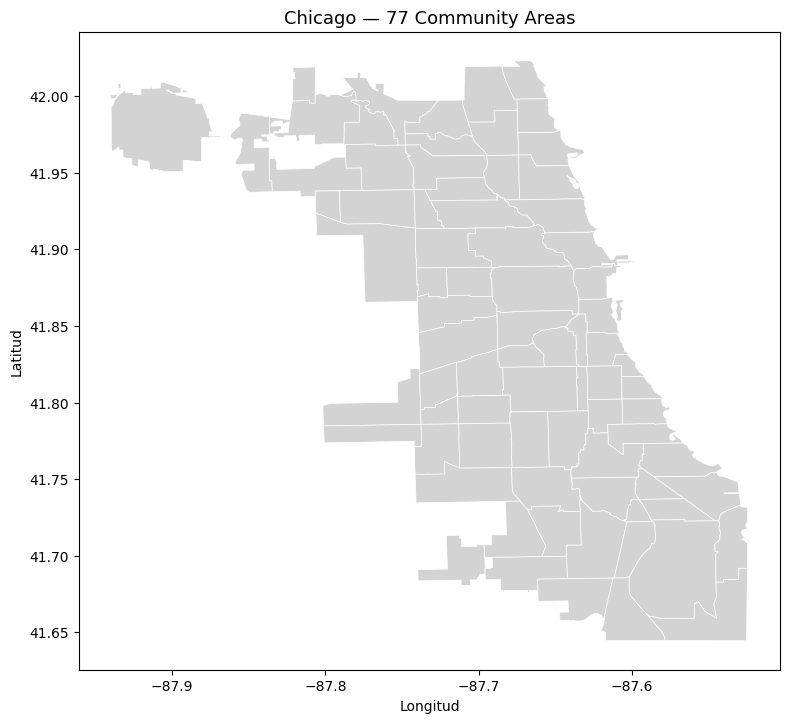

In [11]:
# Visualizar el mapa de Chicago con los 77 community areas
fig, ax = plt.subplots(figsize=(8, 8))  # Crea una figura y eje, ajuste el tamano

comunidades.plot(
    ax=ax,                # Dibuja el mapa sobre el eje creado
    color='lightgray',    # Color de relleno de las comunidades
    edgecolor='white',    # Color de los bordes entre comunidades
    linewidth=0.5         # Grosor de los bordes
)

ax.set_title('Chicago — 77 Community Areas', fontsize=13)  # Título del mapa
ax.set_xlabel('Longitud')  # Etiqueta del eje X
ax.set_ylabel('Latitud')   # Etiqueta del eje Y

ax.set_aspect('equal')  # Mantiene la misma escala en ambos ejes (evita distorsiones)

plt.tight_layout()  # Ajusta automáticamente los espacios de la figura
plt.show()          # Muestra el mapa en pantalla

## 6. Superposición: viajes sobre el mapa de Chicago

Antes de hacer el spatial join, veamos cómo se distribuyen los puntos de inicio de los viajes sobre el mapa de la ciudad. Graficamos una muestra para no saturar la visualización.

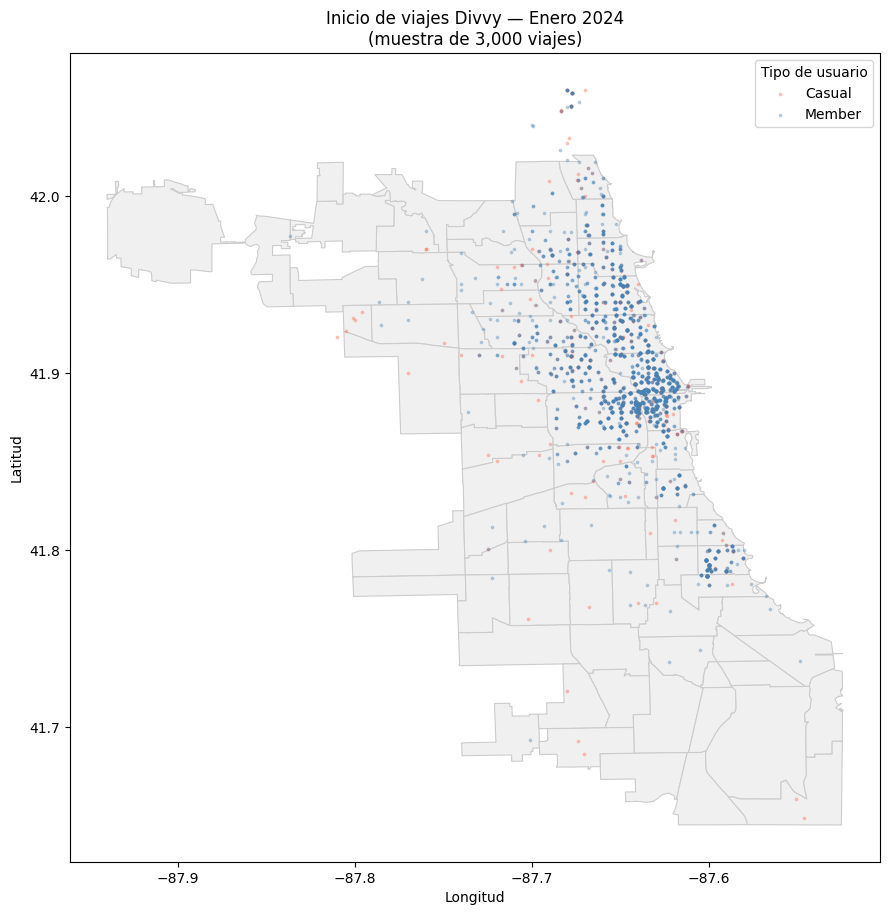

In [12]:
# Tomar una muestra para la visualización (graficar todo sería muy pesado)
muestra = gdf.sample(3000, random_state=42)

fig, ax = plt.subplots(figsize=(9, 11))  # Crea la figura y los ejes

# Dibujar las comunidades de Chicago como mapa de fondo
comunidades.plot(
    ax=ax,
    color='#f0f0f0',      # Color de relleno de las comunidades
    edgecolor='#cccccc',  # Color de los bordes
    linewidth=0.8         # Grosor de los bordes
)

# Dibujar encima los puntos de inicio de los viajes (dictionary to store the info)
colores_usuario = {
    'member': 'steelblue',  # Color para usuarios miembros
    'casual': 'tomato'      # Color para usuarios casuales
}

# Agrupa los datos por tipo de usuario y grafica cada grupo por separado
for tipo, grupo in muestra.groupby('member_casual'):

    grupo.plot(
        ax=ax,
        color=colores_usuario[tipo],  # Usa el color correspondiente
        alpha=0.3,                    # Transparencia para evitar saturación visual
        markersize=3,                 # Tamaño de cada punto
        label=tipo.capitalize()       # Etiqueta para la leyenda
    )

# Personalizar el gráfico
ax.set_title(
    'Inicio de viajes Divvy — Enero 2024\n(muestra de 3,000 viajes)',
    fontsize=12
)

ax.set_xlabel('Longitud')  # Eje X
ax.set_ylabel('Latitud')   # Eje Y

ax.legend(
    title='Tipo de usuario',
    fontsize=10
)  # Muestra la leyenda

ax.set_aspect('equal')  # Mantiene las proporciones geográficas correctas

plt.tight_layout()  # Ajusta espacios automáticamente
plt.show()          # Muestra el mapa

## 7. El problema de las distancias: CRS geográfico vs métrico

Divvy incluye coordenadas de inicio y fin de cada viaje. Podemos calcular la distancia en línea recta entre ambos puntos. Pero si lo hacemos directamente con EPSG:4326, el resultado está en **grados**, no en metros.

Primero demostramos el problema, luego lo corregimos.

In [13]:
# Selecciona el primer viaje (y asegurate que tiene coordenadas válidas de inicio y fin)
viaje = gdf.dropna(subset=['end_lat', 'end_lng']).iloc[0]

# Crea un punto geográfico para el origen del viaje
punto_inicio = Point(viaje['start_lng'], viaje['start_lat'])

# Crea un punto geográfico para el destino del viaje
punto_fin = Point(viaje['end_lng'], viaje['end_lat'])

# Calcula la distancia entre ambos puntos usando coordenadas GPS (lat/lon)
dist_grados = punto_inicio.distance(punto_fin)


print("Viaje de ejemplo:")
print(f"  Inicio: ({viaje['start_lat']:.5f}, {viaje['start_lng']:.5f})")
print(f"  Fin:    ({viaje['end_lat']:.5f},   {viaje['end_lng']:.5f})")
print()
print(f"Distancia con EPSG:4326: {dist_grados:.6f} (en grados, no útil)")

Viaje de ejemplo:
  Inicio: (41.90327, -87.63474)
  Fin:    (41.88918,   -87.63851)

Distancia con EPSG:4326: 0.014586 (en grados, no útil)


### Proyección a CRS métrico

Para Chicago usamos **EPSG:26916** (UTM Zone 16N), un CRS proyectado en metros ideal para el área de Illinois. La proyección se hace con `.to_crs()`.

NB: Los CRS proyectados suelen estar diseñados para regiones específicas. Elegimos uno que funcione bien en el área de estudio para minimizar la distorsión de distancias y áreas. Para Chicago usamos EPSG:26916 porque está optimizado para esa región. Si trabajáramos en otro país, probablemente usaríamos otro CRS más adecuado para esa zona geográfica.

In [14]:
# Proyectar el GeoDataFrame a metros
gdf_metros = gdf.to_crs('EPSG:26916')

print("CRS original:   ", gdf.crs)
print("CRS proyectado: ", gdf_metros.crs)
print()
print("Coordenadas del mismo punto:")
print(f"  EPSG:4326  → {gdf.geometry.iloc[0]}")
print(f"  EPSG:26916 → {gdf_metros.geometry.iloc[0]}")

CRS original:    EPSG:4326
CRS proyectado:  EPSG:26916

Coordenadas del mismo punto:
  EPSG:4326  → POINT (-87.634736776 41.903267384)
  EPSG:26916 → POINT (447352.9528011331 4639230.972902976)


In [15]:
# Ahora calcular distancia real en metros para el viaje de ejemplo
# Necesitamos proyectar los puntos individuales también

# Conserva solo los viajes que tienen coordenadas de destino válidas
gdf_trips = gdf.dropna(subset=['end_lat', 'end_lng']).copy()

# Crea una nueva columna con la geometría de destino de cada viaje
gdf_trips['end_geometry'] = [
    Point(lon, lat)  # Construye un Point usando longitud y latitud de destino (list comprehension: para cada par longitud-latitud del dataset, creamos un objeto Point)
    for lon, lat in zip(
        gdf_trips['end_lng'],  # Columna de longitudes de destino
        gdf_trips['end_lat']   # Columna de latitudes de destino
    )
]

# ALTERNATIVE:
# Crea los puntos de destino a partir de las columnas de longitud y latitud
gdf_trips['end_geometry'] = gpd.points_from_xy(
    gdf_trips['end_lng'],
    gdf_trips['end_lat']
)

# Proyecta el GeoDataFrame a un CRS en metros (UTM zona 16N)
gdf_trips_proj = gdf_trips.to_crs('EPSG:26916')  # ahora, gdf_trips_proj.geometry tiene start points en metros

# Convierte la geometría de destino a una GeoSeries y la proyecta al mismo CRS (Una GeoSeries es una columna de geometrías (Point, LineString, Polygon))
end_geoseries_proj = gpd.GeoSeries(
    gdf_trips['end_geometry'],  # Puntos de destino
    crs='EPSG:4326'             # CRS original (latitud/longitud)
).to_crs('EPSG:26916')          # CRS proyectado en metros
# Ahora, end_geoseries_proj tiene end points en metros tambien

# Calcula la distancia entre el punto de inicio y el punto de destino de cada viaje
# Como ambas geometrías están en EPSG:26916, el resultado queda en metros
gdf_trips_proj['distancia_m'] = gdf_trips_proj.geometry.distance(end_geoseries_proj)
# "A.geometry.distance(B)"" funciona solo si A y B tienen:
# misma length, índices alineados y tipos de geometría compatibles

print("Distancias en línea recta (metros):")
print(gdf_trips_proj['distancia_m'].describe().round(0))

Distancias en línea recta (metros):
count    139704.0
mean       1748.0
std        1554.0
min           0.0
25%         810.0
50%        1297.0
75%        2168.0
max       24871.0
Name: distancia_m, dtype: float64


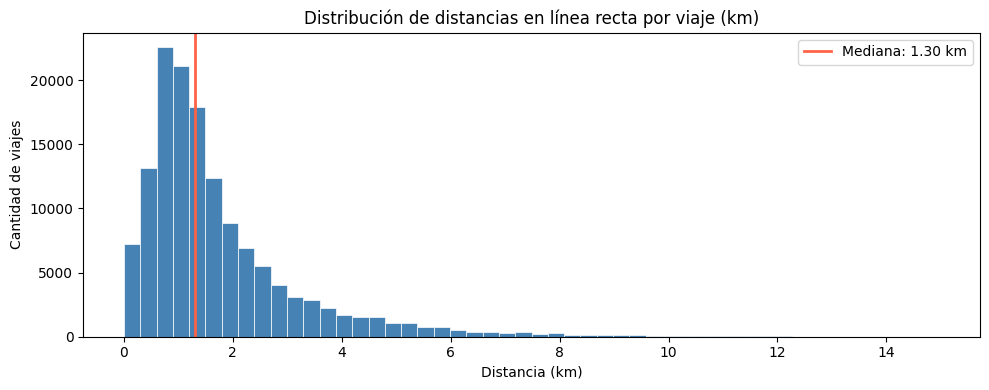

In [16]:
# Histograma de distancias
distancias_km = gdf_trips_proj['distancia_m'] / 1000
distancias_km = distancias_km[distancias_km < 15]  # filtrar outliers extremos

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(distancias_km, bins=50, color='steelblue', edgecolor='white', linewidth=0.5)
ax.set_title('Distribución de distancias en línea recta por viaje (km)')
ax.set_xlabel('Distancia (km)')
ax.set_ylabel('Cantidad de viajes')
ax.axvline(distancias_km.median(), color='tomato', linewidth=2,
           label=f'Mediana: {distancias_km.median():.2f} km')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Exploración espacial: extensión del dataset

Vamos a ver qué son los *spatial joins*. Pero antes de poder hacer un spatial join, calculamos los *bounding boxes* para comprobar que ambos datasets son compatibles en el espacio y que realmente se superponen. Así nos aseguramos de que el join dará resultados correctos y no vacíos o incorrectos.


In [20]:
# Bounding box de los viajes
bounds = gdf.total_bounds # returno [minx, miny, maxx, maxy], i.e. smallest longitude, largest longitude, smallest latitude, largest latitude
print("Extensión espacial de los viajes:")
print(f"  Longitud: {bounds[0]:.4f} → {bounds[2]:.4f}")
print(f"  Latitud:  {bounds[1]:.4f} → {bounds[3]:.4f}")
print()

# Bounding box de los community areas
bounds_chi = comunidades.total_bounds
print("Extensión espacial de Chicago (community areas):")
print(f"  Longitud: {bounds_chi[0]:.4f} → {bounds_chi[2]:.4f}")
print(f"  Latitud:  {bounds_chi[1]:.4f} → {bounds_chi[3]:.4f}")

Extensión espacial de los viajes:
  Longitud: -87.8441 → -87.5284
  Latitud:  41.6486 → 42.0700

Extensión espacial de Chicago (community areas):
  Longitud: -87.9401 → -87.5241
  Latitud:  41.6445 → 42.0230


## 9. Spatial Join: ¿en qué community area inicia cada viaje?

El `sjoin` nos permite asignar a cada punto de Divvy el community area en el que se encuentra. Es equivalente a un `merge`, pero la condición de unión es geográfica.

```python
gpd.sjoin(gdf_puntos, gdf_poligonos, how='left', predicate='within')
```

Usamos `how='left'` para conservar todos los viajes, incluso los que queden fuera de los polígonos (por ejemplo, viajes que empezaron en Evanston, fuera de Chicago).

In [21]:
# Aseguramos que ambos GeoDataFrames tienen el mismo CRS
print("CRS viajes:     ", gdf.crs)
print("CRS comunidades:", comunidades.crs)

CRS viajes:      EPSG:4326
CRS comunidades: EPSG:4326


In [26]:
# Spatial join: asignar community area a cada viaje
gdf_joined = gpd.sjoin(
    gdf,  # puntos de viajes (cada viaje tiene una ubicación)
    comunidades[['community', 'area_num_1', 'geometry']], # dataset de polígonos (barrios). solo quedamos con este 3 columnias (nombre del barrio, ID del area y forma del polygono)
    how='left', # hacemos un left join, que mantiene todos los viajes aunque no encuentren un barrio correspondiente
    predicate='within' # condición espacial: cada punto (viaje) debe estar DENTRO de un polígono (barrio)
    # si está dentro → se asigna ese barrio
    # si no está dentro → queda NaN
)

print(f"Filas antes del join:  {len(gdf):,}")
print(f"Filas después del join: {len(gdf_joined):,}")
print(f"Viajes sin community area: {gdf_joined['community'].isnull().sum():,}")
print()
gdf_joined[['ride_id', 'rideable_type', 'member_casual', 'duracion_min', 'community']].head(8)

Filas antes del join:  139,704
Filas después del join: 139,704
Viajes sin community area: 1,706



,ride_id,rideable_type,member_casual,duracion_min,community
0,C1D650626C8C899A,electric_bike,member,7.533333,Near North Side
1,EECD38BDB25BFCB0,electric_bike,member,7.216667,Near North Side
2,F4A9CE78061F17F7,electric_bike,member,8.000000,Near North Side
3,0A0D9E15EE50B171,classic_bike,member,29.816667,Loop
4,33FFC9805E3EFF9A,classic_bike,member,26.200000,North Center
5,C96080812CD285C5,classic_bike,member,8.650000,Near North Side
6,0EA7CB313D4F456A,classic_bike,member,8.900000,Near North Side
7,EE11F3A3B39CFBD8,electric_bike,member,8.183333,Near North Side


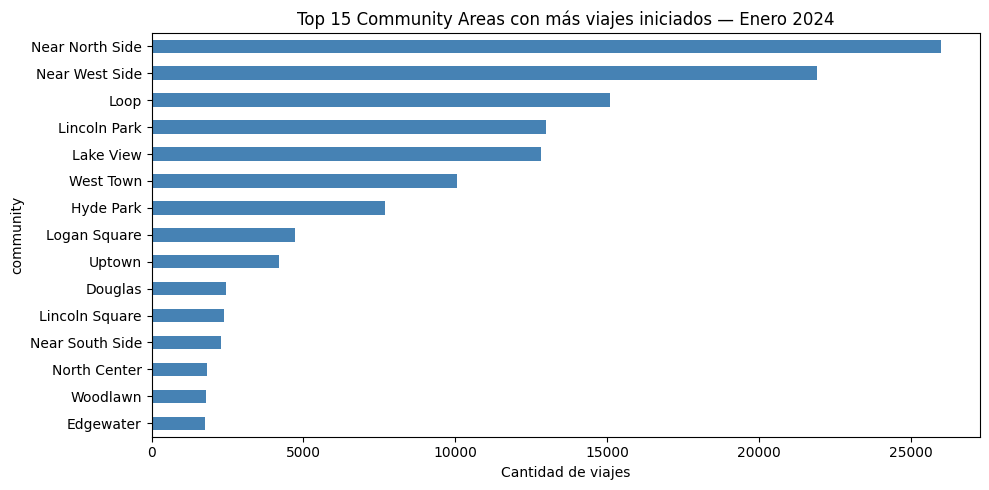

In [28]:
# Top 15 community areas con más viajes iniciados
top_areas = (
    gdf_joined['community'] # selecciona la columna "community" (nombre del barrio asignado a cada viaje)
    .value_counts() # cuenta cuántas veces aparece cada barrio (número de viajes por comunidad)
    .head(15)
)

fig, ax = plt.subplots(figsize=(10, 5))
top_areas.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 15 Community Areas con más viajes iniciados — Enero 2024')
ax.set_xlabel('Cantidad de viajes')
plt.tight_layout()
plt.show()

## 10. Mapa de calor por community area

Combinamos el conteo de viajes por community area con el GeoDataFrame de polígonos para hacer un **mapa de coropletas** — un mapa donde el color de cada zona refleja un valor numérico.

In [45]:
# Calcular métricas por community area
metricas = (
    gdf_joined # dataset ya joined con las communities
    .groupby('community') # agrupa todos los viajes por community
    .agg(
        total_viajes=('ride_id', 'count'),  # cuenta cuántos viajes hay en cada comunidad
        duracion_promedio=('duracion_min', 'mean') # calcula la duración promedio de los viajes en minutos
    )
    .round(1) # redondea el resultado a 1 decimal
    .reset_index() # convierte el índice (community) de nuevo en columna
)

# Unir al GeoDataFrame de polígonos
# (tenemos que unir las métricas con el GeoDataFrame para que cada polígono geográfico (área comunitaria) contenga sus estadísticas calculadas,
# lo que nos permite visualizar y analizar los datos de forma espacial en un mapa.)
comunidades_metricas = comunidades.merge(metricas, on='community', how='left') # añade las métricas a los polígonos de las comunidades

# reemplaza valores NaN por 0 (barrios sin viajes registrados)
comunidades_metricas['total_viajes'] = comunidades_metricas['total_viajes'].fillna(0)

print(f"Community areas con datos: {metricas.shape[0]}")
metricas.sort_values('total_viajes', ascending=False).head(10)

Community areas con datos: 75


,community,total_viajes,duracion_promedio
46,Near North Side,25987,10.3
48,Near West Side,21908,9.5
40,Loop,15115,11.0
37,Lincoln Park,12982,10.3
36,Lake View,12812,9.5
73,West Town,10063,10.6
32,Hyde Park,7700,8.1
39,Logan Square,4716,11.4
64,Uptown,4190,10.2
16,Douglas,2464,8.8


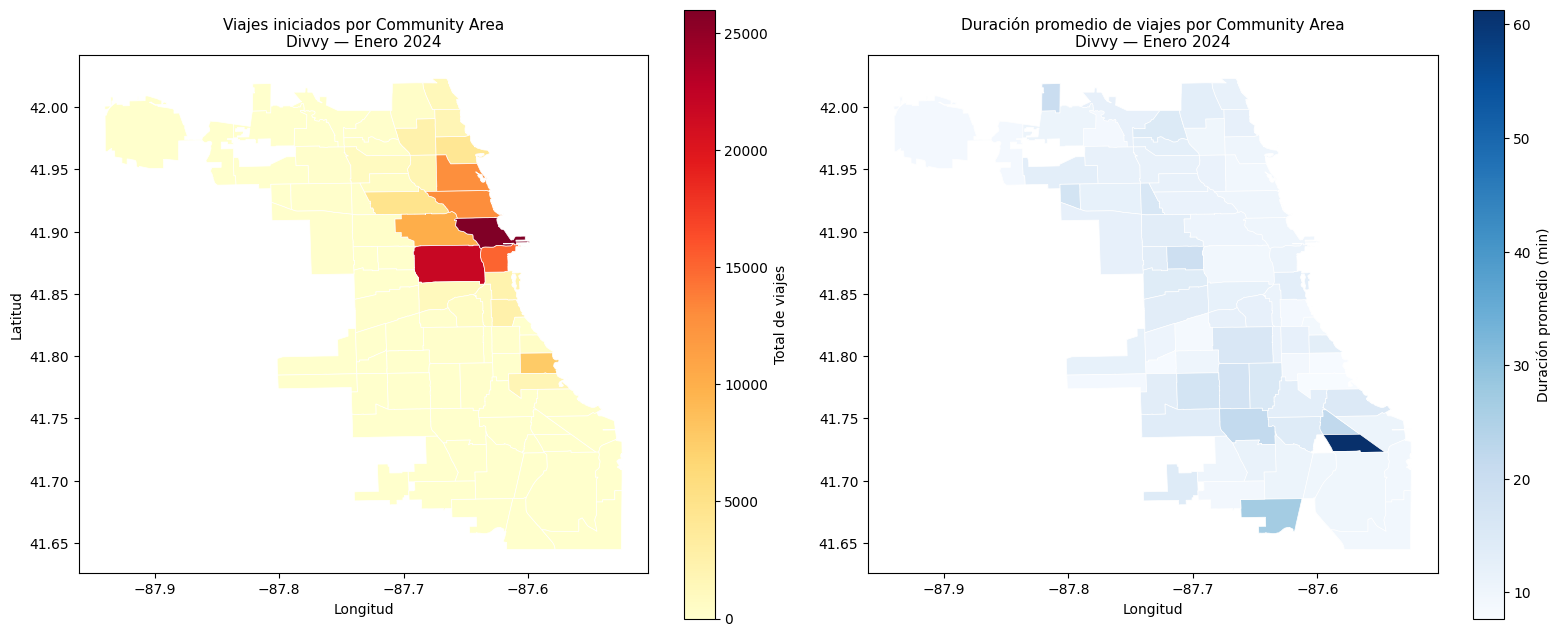

In [53]:
# Mapa de coropletas: total de viajes por community area
fig, axes = plt.subplots(1, 2, figsize=(16, 9))  # crea dos subgráficos lado a lado

# --- Mapa izquierdo: total de viajes ---
comunidades_metricas.plot(
    ax=axes[0],  # primer mapa (izquierda)
    column='total_viajes',  # variable que se visualiza
    cmap='YlOrRd',  # escala de colores (amarillo → rojo)
    edgecolor='white',  # bordes blancos entre polígonos
    linewidth=0.5,  # grosor de los bordes
    legend=True,  # muestra barra de color
    legend_kwds={'label': 'Total de viajes', 'shrink': 0.7}  # etiqueta de la leyenda
)
axes[0].set_title('Viajes iniciados por Community Area\nDivvy — Enero 2024', fontsize=11)  # título del mapa izquierdo
axes[0].set_xlabel('Longitud')  # etiqueta eje X
axes[0].set_ylabel('Latitud')  # etiqueta eje Y
axes[0].set_aspect('equal')  # mantiene proporción espacial correcta

# --- Mapa derecho: duración promedio ---
comunidades_metricas.plot(
    ax=axes[1],  # segundo mapa (derecha)
    column='duracion_promedio',  # variable a visualizar
    cmap='Blues',  # escala de azules
    edgecolor='white',  # bordes de polígonos
    linewidth=0.5,  # grosor de líneas
    legend=True,  # barra de color
    legend_kwds={'label': 'Duración promedio (min)', 'shrink': 0.7}  # etiqueta de leyenda
)
axes[1].set_title('Duración promedio de viajes por Community Area\nDivvy — Enero 2024', fontsize=11)  # título derecho
axes[1].set_xlabel('Longitud')  # etiqueta eje X
axes[1].set_aspect('equal')  # mantiene proporción espacial

plt.tight_layout()  # ajusta espacios entre gráficos
plt.show()  # muestra la figura final

## 11. Guardar para la Fase 3

In [ ]:
# Guardar el GeoDataFrame con community area asignado
cols_exportar = ['ride_id', 'started_at', 'rideable_type', 'member_casual',
                 'duracion_min', 'hora', 'dia_semana',
                 'start_lat', 'start_lng', 'community', 'area_num_1']

export = gdf_joined[cols_exportar].copy()
export['started_at'] = export['started_at'].astype(str)
export.to_csv('divvy_enero2024_geo.csv', index=False)

print(f"Guardado 'divvy_enero2024_geo.csv': {len(export):,} filas")

---

**Fin de la Fase 2.**  
En la siguiente sesión: Fase 3 — Combinación temporal + espacial y visualizaciones integradas.